# BME 574 — How the classifier works
### Nearest centroid, built from scratch on made-up data

In Project 1 you fill in two small functions, `fit_centroids` and `predict`. This notebook
explains what they do and why, using artificial data simple enough to draw. Nothing here is real
— that is the point. When you can see every point on a plot, you can check your intuition against
the picture.

**Run every cell in order.** There is nothing to fill in; this is a read-and-run notebook. About
25 minutes.

---

### What we are going to establish

1. A classifier is a rule that turns a measurement into a guess about a label.
2. **Nearest centroid** is about the simplest sensible rule there is: find the average of each
   class, then assign a new point to whichever average it is closest to.
3. Its decision boundary is a straight line, which tells you exactly when it works and when it
   does not.
4. Accuracy on its own is a misleading number, and what it must be compared against.
5. Why the project projects onto components *before* classifying — and what that does and does
   not buy you.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

BLUE, RED = '#2c6fbb', '#c0392b'
print('ready')

ready


---
# Part 1 · The idea, in two dimensions

## 1.1 · Some made-up measurements

Imagine each patient gives you two numbers. Maybe two blood markers; it does not matter. Each
patient belongs to one of two classes, and we know which — this is our **training data**.

Z (120, 2)   <- 120 patients, 2 measurements each
y (120,)   <- one label per patient


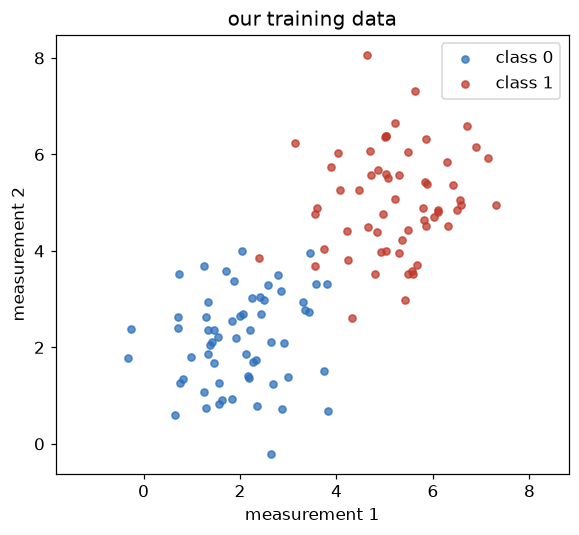

In [2]:
n_per = 60
A = rng.normal([2.0, 2.0], 1.0, size=(n_per, 2))    # class 0
B = rng.normal([5.5, 5.0], 1.0, size=(n_per, 2))    # class 1

Z = np.vstack([A, B])                                # the data matrix, 120 x 2
y = np.array([0] * n_per + [1] * n_per)              # the labels

print('Z', Z.shape, '  <- 120 patients, 2 measurements each')
print('y', y.shape, '  <- one label per patient')

plt.figure(figsize=(5.4, 5))
plt.scatter(*Z[y == 0].T, c=BLUE, s=22, label='class 0', alpha=.75)
plt.scatter(*Z[y == 1].T, c=RED, s=22, label='class 1', alpha=.75)
plt.xlabel('measurement 1'); plt.ylabel('measurement 2')
plt.title('our training data'); plt.legend(); plt.axis('equal')
plt.tight_layout(); plt.show()

## 1.2 · The centroid is just the average

A **centroid** is the mean position of a class — the centre of its cloud. One line each, and it
is exactly the `.mean(axis=0)` from the primer: the row axis disappears, leaving one number per
measurement.

centroid of class 0: [2.   2.16]
centroid of class 1: [5.22 5.03]


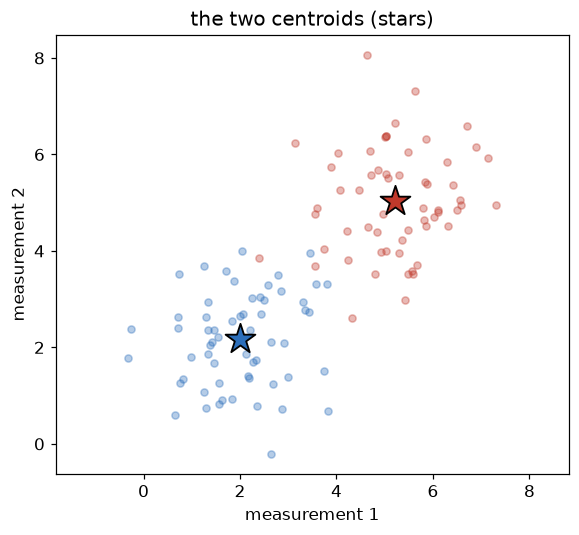

In [3]:
centroid_0 = Z[y == 0].mean(axis=0)
centroid_1 = Z[y == 1].mean(axis=0)

print('centroid of class 0:', centroid_0.round(2))
print('centroid of class 1:', centroid_1.round(2))

plt.figure(figsize=(5.4, 5))
plt.scatter(*Z[y == 0].T, c=BLUE, s=22, alpha=.35)
plt.scatter(*Z[y == 1].T, c=RED, s=22, alpha=.35)
plt.scatter(*centroid_0, c=BLUE, s=420, marker='*', edgecolor='k', lw=1.2, zorder=5)
plt.scatter(*centroid_1, c=RED, s=420, marker='*', edgecolor='k', lw=1.2, zorder=5)
plt.xlabel('measurement 1'); plt.ylabel('measurement 2')
plt.title('the two centroids (stars)'); plt.axis('equal')
plt.tight_layout(); plt.show()

## 1.3 · Classifying one new patient, by hand

A new patient arrives. We do not know their class. Measure the distance from their point to each
centroid, and guess whichever is nearer. That is the entire method.

Distance between two points is Pythagoras: $\sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}$.

distance to centroid 0: 2.46
distance to centroid 1: 1.88

--> our guess: class 1


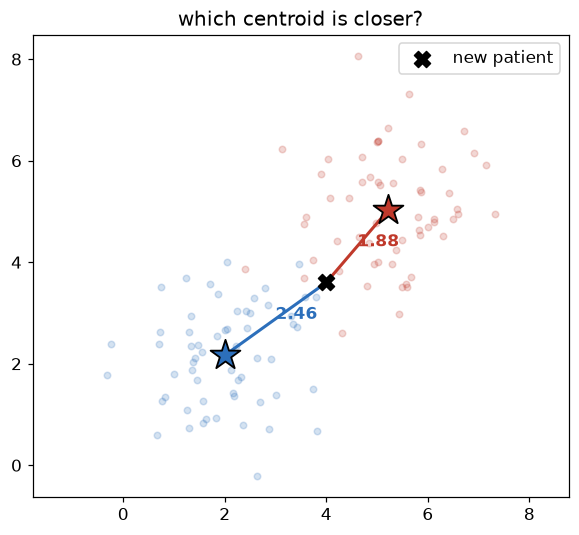

In [4]:
new_patient = np.array([4.0, 3.6])

d0 = np.sqrt(((new_patient - centroid_0) ** 2).sum())
d1 = np.sqrt(((new_patient - centroid_1) ** 2).sum())

print(f'distance to centroid 0: {d0:.2f}')
print(f'distance to centroid 1: {d1:.2f}')
print()
print(f'--> our guess: class {0 if d0 < d1 else 1}')

plt.figure(figsize=(5.4, 5))
plt.scatter(*Z[y == 0].T, c=BLUE, s=18, alpha=.2)
plt.scatter(*Z[y == 1].T, c=RED, s=18, alpha=.2)
for cen, col, dd in [(centroid_0, BLUE, d0), (centroid_1, RED, d1)]:
    plt.plot([new_patient[0], cen[0]], [new_patient[1], cen[1]], color=col, lw=2)
    mid = (new_patient + cen) / 2
    plt.text(mid[0], mid[1], f'{dd:.2f}', color=col, fontsize=11, fontweight='bold')
    plt.scatter(*cen, c=col, s=420, marker='*', edgecolor='k', lw=1.2, zorder=5)
plt.scatter(*new_patient, c='k', s=110, marker='X', zorder=6, label='new patient')
plt.legend(); plt.axis('equal'); plt.title('which centroid is closer?')
plt.tight_layout(); plt.show()

> **A shortcut worth knowing.** Comparing $\sqrt{a}$ and $\sqrt{b}$ gives the same answer as
> comparing $a$ and $b$, because the square root never changes which is bigger. So we usually
> skip the `np.sqrt` and compare **squared** distances — same decision, less arithmetic. That is
> why the project's code has `** 2` and no square root.

## 1.4 · Classifying many patients at once

Doing that one patient at a time works. Here it is as a loop, which is easy to read:

In [5]:
def predict_loop(points, centroids):
    """The obvious version: one point at a time."""
    guesses = []
    for point in points:
        distances = [((point - c) ** 2).sum() for c in centroids]
        guesses.append(np.argmin(distances))
    return np.array(guesses)


centroids = np.stack([centroid_0, centroid_1])
test_points = np.array([[4.0, 3.6], [1.0, 1.0], [6.0, 6.0], [3.8, 3.8]])
print('loop version    :', predict_loop(test_points, centroids))

loop version    : [1 0 1 1]


And here is the version the project uses. It does the same thing without a loop, which matters
when you have 20,000 observations instead of four.

The only unfamiliar part is `[:, None, :]`, which inserts an empty axis so that NumPy compares
**every point against every centroid** in one go — broadcasting, from primer section 8.

```
points     (n_points,           1, n_features)
centroids  (        1, n_classes, n_features)
difference (n_points, n_classes, n_features)   <- every pair
sum over the last axis -> (n_points, n_classes) distances
```

You do not have to love this line. You do have to recognize it — and the cell below proves the
two versions agree, which is the kind of check the course is built around.

In [6]:
def predict_fast(points, centroids):
    d = ((points[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=-1)
    return np.argmin(d, axis=1)


print('vectorised version:', predict_fast(test_points, centroids))
print()

big = rng.normal(3.5, 2.5, size=(500, 2))
assert (predict_loop(big, centroids) == predict_fast(big, centroids)).all()
print('the two versions agree on 500 random points — they are the same method.')

vectorised version: [1 0 1 1]

the two versions agree on 500 random points — they are the same method.


## 1.5 · The decision boundary is a straight line

Rather than guess when this rule works, let us colour **every** point in the plane by what it
would be classified as. The border between the colours is the *decision boundary*.

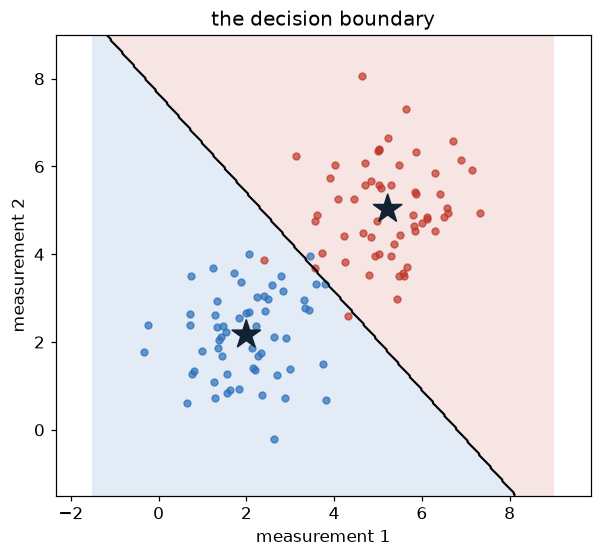

The boundary is the set of points equally far from both centroids:
a straight line, perpendicular to the line joining them, halfway along.


In [7]:
gx, gy = np.meshgrid(np.linspace(-1.5, 9, 320), np.linspace(-1.5, 9, 320))
grid = np.column_stack([gx.ravel(), gy.ravel()])
zone = predict_fast(grid, centroids).reshape(gx.shape)

plt.figure(figsize=(5.6, 5.2))
plt.contourf(gx, gy, zone, levels=[-.5, .5, 1.5], colors=[BLUE, RED], alpha=.13)
plt.contour(gx, gy, zone, levels=[.5], colors='k', linewidths=1.4)
plt.scatter(*Z[y == 0].T, c=BLUE, s=20, alpha=.7)
plt.scatter(*Z[y == 1].T, c=RED, s=20, alpha=.7)
plt.scatter(*centroids.T, c=['#123', '#123'], s=380, marker='*', zorder=5)
plt.xlabel('measurement 1'); plt.ylabel('measurement 2')
plt.title('the decision boundary'); plt.axis('equal')
plt.tight_layout(); plt.show()

print('The boundary is the set of points equally far from both centroids:')
print('a straight line, perpendicular to the line joining them, halfway along.')

> **This is the key fact about nearest centroid.** Its boundary is always straight. That makes it
> fast, stable with very little data, and impossible to overfit badly — and it also means it
> cannot represent a curved boundary no matter how much data you give it. Part 2 shows what that
> costs.

---
## 1.6 · Accuracy, and why it lies

Accuracy is the fraction of guesses that are right. It is the obvious score and it is dangerously
easy to misread.

In [8]:
pred = predict_fast(Z, centroids)
print(f'accuracy on our training data: {(pred == y).mean():.3f}')

accuracy on our training data: 0.975


That looks good. Now watch what happens when one class is much commoner than the other — which
is the normal situation in medicine, where most people do not have the disease.

In [9]:
# 95 patients of class 0, only 5 of class 1
Zi = np.vstack([rng.normal([2, 2], 1.0, (95, 2)), rng.normal([2.6, 2.6], 1.0, (5, 2))])
yi = np.array([0] * 95 + [1] * 5)

ci = np.stack([Zi[yi == c].mean(axis=0) for c in [0, 1]])
pi = predict_fast(Zi, ci)

lazy = np.zeros(len(yi), dtype=int)        # a 'classifier' that always says class 0

header = '{:22s} {:>9s} {:>12s} {:>12s}'.format('', 'accuracy', 'recall c0', 'recall c1')
print(header)
print('-' * len(header))
for name, guess in [('our classifier', pi), ('always guess class 0', lazy)]:
    r0 = (guess[yi == 0] == 0).mean()
    r1 = (guess[yi == 1] == 1).mean()
    print(f'{name:22s} {(guess == yi).mean():9.3f} {r0:12.3f} {r1:12.3f}')
print()
print('Look at that table again before you move on.')
print()
print('The lazy rule scores HIGHER on accuracy — and its recall on the rare class')
print('is exactly zero. It never identifies a single patient who has the condition.')
print('Our classifier scores LOWER on accuracy while catching most of them.')
print()
print('By accuracy, the useless model wins. That is not a quirk of this example;')
print('it is what accuracy does whenever one class is rare, which in medicine is')
print('almost always.')

                        accuracy    recall c0    recall c1
----------------------------------------------------------
our classifier             0.690        0.684        0.800
always guess class 0       0.950        1.000        0.000

Look at that table again before you move on.

The lazy rule scores HIGHER on accuracy — and its recall on the rare class
is exactly zero. It never identifies a single patient who has the condition.
Our classifier scores LOWER on accuracy while catching most of them.

By accuracy, the useless model wins. That is not a quirk of this example;
it is what accuracy does whenever one class is rare, which in medicine is
almost always.


> **Three rules that follow.**
> 1. Always report the **majority baseline** next to your accuracy. Here it is 0.95, and beating
>    it is genuinely hard — which is the point.
> 2. Always report **per-class rates**. They are what exposed the lazy rule, and the overall
>    number hid it completely.
> 3. **Decide what matters before you measure.** For a screening test, missing a case is far
>    worse than a false alarm, so recall on the rare class is the number to optimize — and you
>    would happily accept our 0.69-accuracy classifier over the 0.95 one.

Every biomedical track in Project 1 is imbalanced, so this is not a footnote. It is why the memo
asks for per-class rates rather than a single score.

## 1.7 · Never score on the data you fitted

The centroids were computed *from* the training points, so scoring on those same points flatters
you. The honest question is how well the rule does on patients it has never seen.

In [10]:
idx = rng.permutation(len(Z))
tr, te = idx[:80], idx[80:]

cen_tr = np.stack([Z[tr][y[tr] == c].mean(axis=0) for c in [0, 1]])

acc_train = (predict_fast(Z[tr], cen_tr) == y[tr]).mean()
acc_test = (predict_fast(Z[te], cen_tr) == y[te]).mean()

print(f'accuracy on the 80 patients we fitted on : {acc_train:.3f}')
print(f'accuracy on the 40 held-out patients     : {acc_test:.3f}   <- the honest number')
print()
print('For this simple rule the gap is small. For flexible models it can be enormous —')
print('which is why the project makes you hold out a test set and never touch it.')

accuracy on the 80 patients we fitted on : 0.963
accuracy on the 40 held-out patients     : 0.975   <- the honest number

For this simple rule the gap is small. For flexible models it can be enormous —
which is why the project makes you hold out a test set and never touch it.


---
# Part 2 · Where this classifier breaks

A straight boundary through the midpoint is a strong assumption. Here are three artificial
datasets that violate it in different ways. Each is one you might genuinely meet.

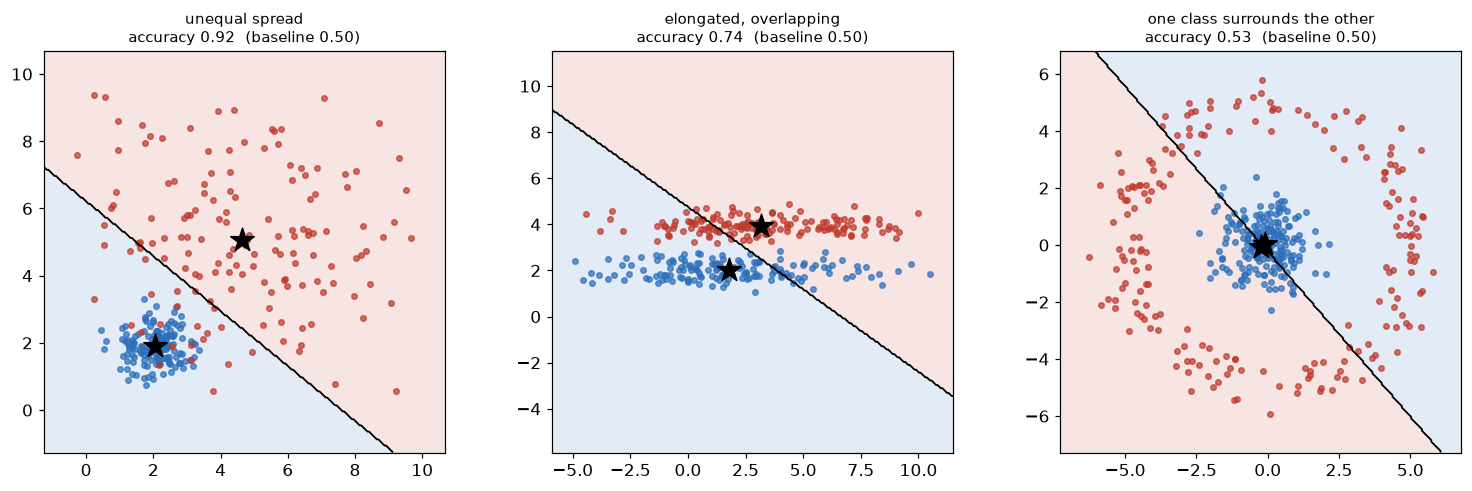

In [11]:
def centroids_of(Z, y):
    return np.stack([Z[y == c].mean(axis=0) for c in np.unique(y)])


def make_unequal_spread(n=150):
    a = rng.normal([2, 2], 0.5, (n, 2))          # tight
    b = rng.normal([5, 5], 2.2, (n, 2))          # broad
    return np.vstack([a, b]), np.array([0] * n + [1] * n)


def make_elongated(n=150):
    a = rng.normal(0, 1, (n, 2)) @ np.array([[3.2, 0], [0, 0.35]]) + [2, 2]
    b = rng.normal(0, 1, (n, 2)) @ np.array([[3.2, 0], [0, 0.35]]) + [3, 4]
    return np.vstack([a, b]), np.array([0] * n + [1] * n)


def make_ring(n=200):
    inner = rng.normal(0, 0.8, (n, 2))
    th = rng.uniform(0, 2 * np.pi, n); r = rng.normal(5, 0.5, n)
    outer = np.column_stack([r * np.cos(th), r * np.sin(th)])
    return np.vstack([inner, outer]), np.array([0] * n + [1] * n)


cases = [('unequal spread', make_unequal_spread()),
         ('elongated, overlapping', make_elongated()),
         ('one class surrounds the other', make_ring())]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (name, (Zc, yc)) in zip(axes, cases):
    cen = centroids_of(Zc, yc)
    lo, hi = Zc.min() - 1, Zc.max() + 1
    gx2, gy2 = np.meshgrid(np.linspace(lo, hi, 260), np.linspace(lo, hi, 260))
    zz = predict_fast(np.column_stack([gx2.ravel(), gy2.ravel()]), cen).reshape(gx2.shape)
    ax.contourf(gx2, gy2, zz, levels=[-.5, .5, 1.5], colors=[BLUE, RED], alpha=.13)
    ax.contour(gx2, gy2, zz, levels=[.5], colors='k', linewidths=1.2)
    ax.scatter(*Zc[yc == 0].T, c=BLUE, s=13, alpha=.7)
    ax.scatter(*Zc[yc == 1].T, c=RED, s=13, alpha=.7)
    ax.scatter(*cen.T, c='k', s=260, marker='*', zorder=5)
    acc = (predict_fast(Zc, cen) == yc).mean()
    ax.set_title(f'{name}\naccuracy {acc:.2f}  (baseline 0.50)', fontsize=10)
    ax.set_aspect('equal')
fig.tight_layout(); plt.show()

Read those three pictures carefully.

- **Unequal spread.** The boundary sits halfway between the centroids, but the broad class
  genuinely reaches further. Points that clearly belong to the broad class get claimed by the
  tight one. A method that accounted for each class's spread would place the line differently.
- **Elongated and overlapping.** The classes differ mostly along their short axis, but
  nearest-centroid measures plain distance and is dominated by the long axis. This is the same
  reason you standardize columns that have different scales.
- **One class surrounds the other.** Accuracy near the baseline. No straight line can separate a
  ring from its centre, so this classifier cannot do it at any amount of data. Not a bug — a
  limit.

> **Why use it anyway?** It has no hyperparameters to tune, it needs very little data, it never
> collapses in high dimensions, and its failures are legible — you can *see* why it went wrong,
> which is exactly what you want in the first project of a course. Later assignments bring models
> that can draw curves.

---
# Part 3 · Why the project projects first

Everything so far had two measurements per patient, so we could draw it. Real data has hundreds
or thousands. Here is an artificial dataset with **400 measurements per patient** — think of it as
a spectrum, or a row of pixels.

It is built from three ingredients, and only one of them carries the class:

X_tr (120, 400)  120 patients, 400 measurements each


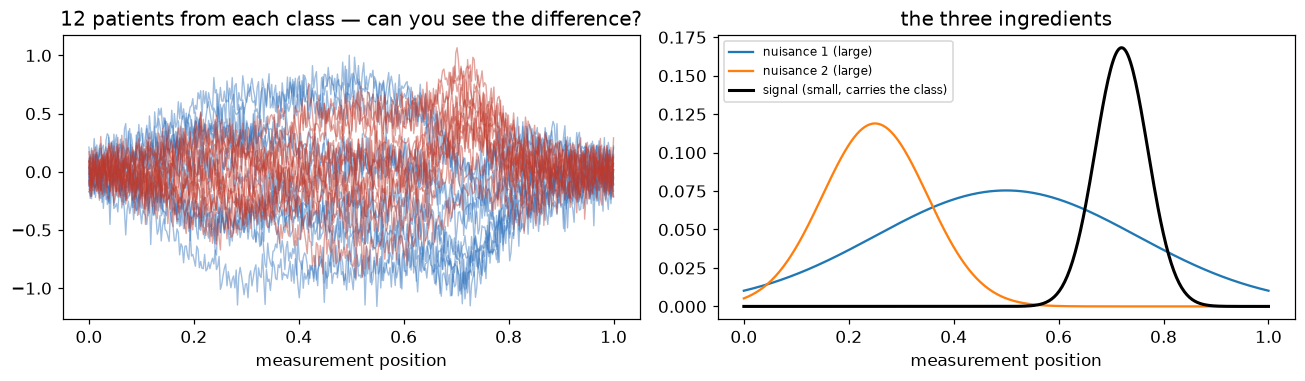

In [12]:
P = 400
t = np.linspace(0, 1, P)


def bump(centre, width):
    b = np.exp(-((t - centre) ** 2) / (2 * width ** 2))
    return b / np.linalg.norm(b)


nuisance_1 = bump(0.50, 0.25)    # big, varies a lot, tells you NOTHING about the class
nuisance_2 = bump(0.25, 0.10)    # also big, also uninformative
signal = bump(0.72, 0.05)        # small, and its size DOES depend on the class


def make_highdim(n):
    lab = rng.integers(0, 2, n)
    X = (rng.normal(0, 6.0, n)[:, None] * nuisance_1
         + rng.normal(0, 3.6, n)[:, None] * nuisance_2
         + (2.5 * (2 * lab - 1) + rng.normal(0, 0.5, n))[:, None] * signal
         + rng.normal(0, 0.10, (n, P)))
    return X, lab


X_tr, y_tr = make_highdim(120)
X_te, y_te = make_highdim(600)
print('X_tr', X_tr.shape, ' 120 patients, 400 measurements each')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for c, col in [(0, BLUE), (1, RED)]:
    for row in X_tr[y_tr == c][:12]:
        ax[0].plot(t, row, color=col, alpha=.45, lw=.9)
ax[0].set(title='12 patients from each class — can you see the difference?',
          xlabel='measurement position')
ax[1].plot(t, nuisance_1, label='nuisance 1 (large)')
ax[1].plot(t, nuisance_2, label='nuisance 2 (large)')
ax[1].plot(t, signal, 'k', lw=2, label='signal (small, carries the class)')
ax[1].set(title='the three ingredients', xlabel='measurement position')
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

You cannot see the difference by eye, and that is realistic. The class effect is small and sits
underneath two much larger sources of variation that have nothing to do with the class — think
overall brightness in an X-ray, or electrode impedance in an EEG.

## 3.1 · What the components find

Take the SVD of the training rows, exactly as in the project, and plot the first few components.
Because each measurement position is a feature, each component is a curve we can draw.

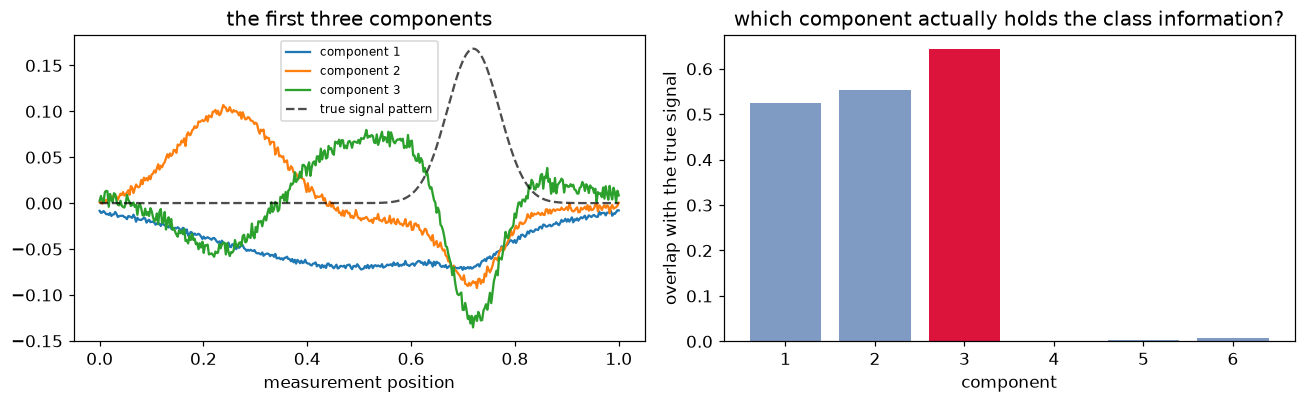

overlap with the signal pattern, per component: [0.53 0.55 0.64 0.   0.   0.01]
the signal mostly lives in component 3, not component 1.

Components 1 and 2 are the two nuisances. They are the largest sources of
variation, so the SVD finds them first — and they are useless for the task.


In [13]:
mu = X_tr.mean(axis=0)
U, s, Vt = np.linalg.svd(X_tr - mu, full_matrices=False)

overlap = np.abs(Vt[:6] @ signal)      # how much of each component is the signal pattern

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for i in range(3):
    ax[0].plot(t, Vt[i], label=f'component {i + 1}')
ax[0].plot(t, signal, 'k--', lw=1.5, alpha=.7, label='true signal pattern')
ax[0].set(title='the first three components', xlabel='measurement position')
ax[0].legend(fontsize=8)

ax[1].bar(np.arange(1, 7), overlap, color=['#7f9bc4'] * 6)
ax[1].bar([int(np.argmax(overlap)) + 1], [overlap.max()], color='crimson')
ax[1].set(xlabel='component', ylabel='overlap with the true signal',
          title='which component actually holds the class information?')
fig.tight_layout(); plt.show()

print('overlap with the signal pattern, per component:', overlap.round(2))
print(f'the signal mostly lives in component {int(np.argmax(overlap)) + 1}, not component 1.')
print()
print('Components 1 and 2 are the two nuisances. They are the largest sources of')
print('variation, so the SVD finds them first — and they are useless for the task.')

> **This is the lesson from the face lecture, in miniature.** The leading components are the
> *biggest* patterns, not the *useful* ones. In the face data the leading modes were lighting
> direction. Here they are two nuisances. In your track they may be brightness, or total power,
> or which scanner was used. Always check where the class information actually sits.

## 3.2 · How many components do you need?

Now classify, keeping only the first `k` components, and sweep `k`. This is Figure 3 of the
project, on data where we know the right answer.

  k=  1   accuracy=0.597
  k=  2   accuracy=0.697
  k=  3   accuracy=0.797
  k=  4   accuracy=0.797
  k=  6   accuracy=0.797
  k= 10   accuracy=0.797
  k= 25   accuracy=0.797
  k= 60   accuracy=0.797

all 400 measurements, no SVD: 0.797
majority baseline           : 0.503


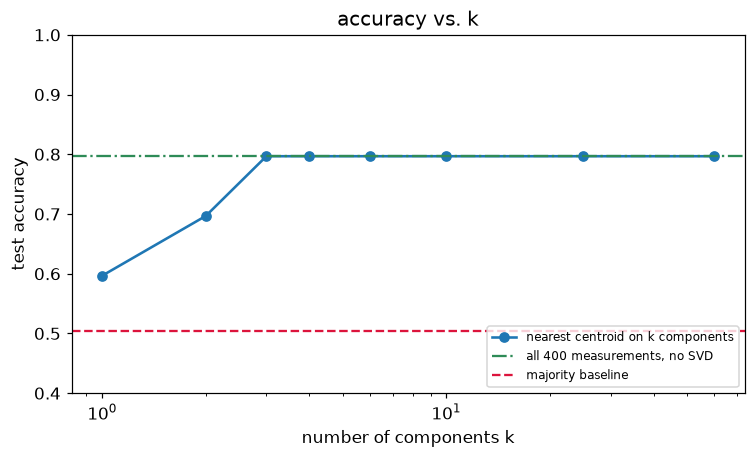

In [14]:
def nc_accuracy(k):
    Ztr = (X_tr - mu) @ Vt[:k].T
    Zte = (X_te - mu) @ Vt[:k].T
    cen = np.stack([Ztr[y_tr == c].mean(axis=0) for c in [0, 1]])
    return (predict_fast(Zte, cen) == y_te).mean()


ks = [1, 2, 3, 4, 6, 10, 25, 60]
accs = [nc_accuracy(k) for k in ks]

cen_raw = np.stack([X_tr[y_tr == c].mean(axis=0) for c in [0, 1]])
raw = (predict_fast(X_te, cen_raw) == y_te).mean()
majority = max(np.bincount(y_te)) / len(y_te)

for k, a in zip(ks, accs):
    print(f'  k={k:3d}   accuracy={a:.3f}')
print()
print(f'all 400 measurements, no SVD: {raw:.3f}')
print(f'majority baseline           : {majority:.3f}')

plt.figure(figsize=(7, 4.3))
plt.semilogx(ks, accs, 'o-', lw=1.7, label='nearest centroid on k components')
plt.axhline(raw, color='seagreen', ls='-.', label='all 400 measurements, no SVD')
plt.axhline(majority, color='crimson', ls='--', label='majority baseline')
plt.xlabel('number of components k'); plt.ylabel('test accuracy')
plt.title('accuracy vs. k'); plt.ylim(0.4, 1.0)
plt.legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()

### Read that plot carefully, because it is the honest answer

**At k = 1 and k = 2 you are near the baseline.** You kept only the two nuisance components and
threw the signal away. Keeping *too few* components is a real failure mode.

**At k = 3 accuracy jumps to the plateau** — that is where the signal component gets included.

**Beyond k = 3, nothing improves.** The extra components are noise; they neither help nor
particularly hurt.

**And the plateau matches using all 400 measurements.** So on this data, projecting did **not**
make the classifier more accurate.

> **That is not a disappointing result, and you should expect it.** What the projection bought
> you is real: 400 numbers per patient reduced to 3, with no loss of accuracy; components you can
> plot and interpret; and a classifier that runs instantly. Project 1's memo question 4 asks
> exactly this — if your no-SVD baseline ties your SVD pipeline, say so plainly and say what the
> decomposition bought instead. That is a correct answer, not a failed one.

---
# Part 4 · The check that catches cheating

Shuffle the training labels so they are pure nonsense, then run the identical pipeline. There is
no longer any relationship to learn, so accuracy **must** fall to roughly the baseline.

If it does not, something in your pipeline is leaking information about the test set — and your
headline number is not real. This costs one line and is the single most valuable check you can
run.

In [15]:
Ztr3 = (X_tr - mu) @ Vt[:3].T
Zte3 = (X_te - mu) @ Vt[:3].T

honest_cen = np.stack([Ztr3[y_tr == c].mean(axis=0) for c in [0, 1]])
honest = (predict_fast(Zte3, honest_cen) == y_te).mean()

shuffled = []
for _ in range(10):
    y_fake = rng.permutation(y_tr)
    cen_f = np.stack([Ztr3[y_fake == c].mean(axis=0) for c in [0, 1]])
    shuffled.append((predict_fast(Zte3, cen_f) == y_te).mean())

print(f'real labels     : {honest:.3f}')
print(f'shuffled labels : {np.mean(shuffled):.3f}  (10 shuffles, spread'
      f' {min(shuffled):.3f}-{max(shuffled):.3f})')
print(f'majority        : {majority:.3f}')
print()
print('The shuffled version collapses to chance, as it must. Our result is real.')

real labels     : 0.797
shuffled labels : 0.487  (10 shuffles, spread 0.260-0.720)
majority        : 0.503

The shuffled version collapses to chance, as it must. Our result is real.


---
# What to take to the project

The two functions you fill in are exactly what you have been reading:

```python
def fit_centroids(Z, y_rows):
    classes = np.unique(y_rows)
    cents = np.stack([Z[y_rows == c].mean(axis=0) for c in classes])
    return classes, cents

def predict(Z, classes, cents):
    d = ((Z[:, None, :] - cents[None, :, :]) ** 2).sum(axis=-1)
    return classes[np.argmin(d, axis=1)]
```

`fit_centroids` is section 1.2 — the average of each class. `predict` is section 1.4 — whichever
average is closest.

### The six things worth remembering

| | |
|---|---|
| **1** | A centroid is a class average. Nearest centroid assigns a point to the closest one. |
| **2** | Its boundary is always a **straight line**. Curved problems are beyond it, by design. |
| **3** | Squared distances give the same answer as distances, so skip the square root. |
| **4** | Accuracy alone lies. Report the **majority baseline** and **per-class rates** beside it. |
| **5** | Score only on data the centroids never saw. |
| **6** | **Shuffle the labels and rerun.** If accuracy survives, you have a leak, not a result. |

### And the one that surprises people

The leading components are the *largest* patterns in your data, which is not the same as the
*useful* ones. In Part 3 the class information sat in component 3, underneath two nuisances. When
you sweep `k` in the project and accuracy is flat until some particular value, that value is
telling you where your signal actually lives.